# GHZ stav: ideální simulátor vs. šumový simulátor (Qiskit Aer)

**Cíl:**
- Připravit $n$‑qubitový GHZ stav,
- spustit jej na **ideálním simulátoru** (bez šumu),
- spustit jej na **šumovém simulátoru** s parametry odpovídajícími dnešním supravodivým qubitům (T₁/T₂, časy bran, depolarizační chyby, čtecí chyba),
- porovnat rozdělení výsledků a jednoduché metriky kvality.

## GHZ stav
$n$‑qubitový GHZ stav definujeme jako
$$ \text{GHZ}_n = \frac{|0\cdots0\rangle + |1\cdots1\rangle}{\sqrt{2}}. $$
Vytvoříme jej tak, že na prvním qubitu aplikujeme Hadamardovu bránu a poté řetězec řízených-X (CX) na zbylé qubity.

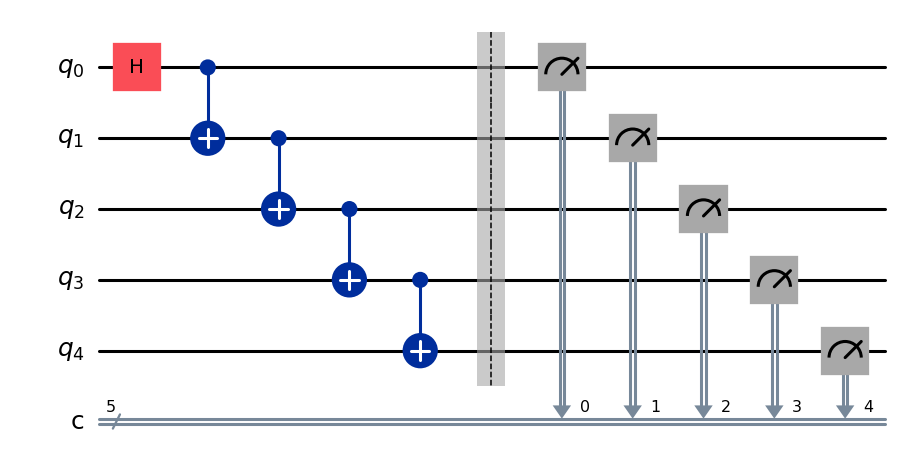

In [79]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from math import pi
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pylab

def ghz_circuit(n: int) -> QuantumCircuit:
    qc = QuantumCircuit(n, n)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    qc.barrier()
    qc.measure(range(n), range(n))
    return qc

n_qubits = 5
qc_ghz = ghz_circuit(n_qubits)
display(qc_ghz.draw('mpl'))

## Ideální simulace (bez šumu)
Na ideálním simulátoru očekáváme téměř veškerou pravděpodobnost ve stavech `00…0` a `11…1` (v poměru ~1:1).

{'00000': 2066, '11111': 2030}


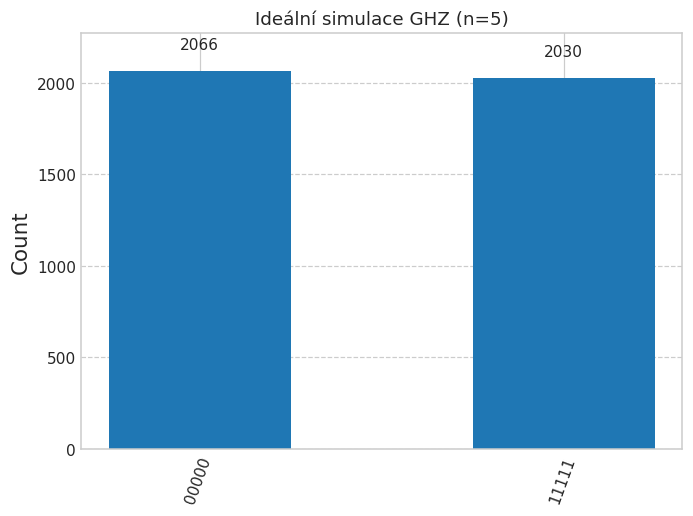

In [80]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

ideal_sim = AerSimulator()  # defaultně bez šumu
qc_t_ideal = transpile(qc_ghz, ideal_sim)
res_ideal = ideal_sim.run(qc_t_ideal, shots=4096).result()
counts_ideal = res_ideal.get_counts()
print(counts_ideal)
plot_histogram(counts_ideal, title=f'Ideální simulace GHZ (n={n_qubits})')

## Šumový model pro dnešní supravodivé qubity
Použijeme jednoduchý, ale realistický model šumu:

**Koherence:**
- $T_1 = 80\,\mu s$ (relaxace, za jak dlouho spadne stav z 1 do 0)
- $T_2 = 60\,\mu s$ (dekoherence fáze. Udává, jak dlouho se udrží relativní fáze qubitu)

**Časy bran:**
- 1q brány: $t_{1q} = 35\,ns$,
- 2q brány (CX): $t_{2q} = 250\,ns$,

**Chybovost bran (modellujeme jako depolarizaci navíc k relaxačním kanálům):**
- 1q depolarizace: $p_{1q} = 1.0\times10^{-3}$,
- 2q depolarizace (CX): $p_{2q} = 1.5\times10^{-2}$,

**Čtecí chyba (readout error):** ~2% symetricky.

Pozn.: Jde o **typické** řády velikostí – konkrétní zařízení se liší čip od čipu i qubit od qubitu. Model skládá **termální relaxaci** (T₁/T₂, přes `thermal_relaxation_error`) s **depolarizační chybou** (`depolarizing_error`) a přidává **čtecí chybu** (`add_readout_error`).

In [81]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
import numpy as np

# Parametry koherence a časů bran
T1 = 200e-6   # 80 microseconds
T2 = 60e-6   # 60 microseconds
t_1q = 35e-9 # 35 ns
t_2q = 250e-9# 250 ns

# Depolarizační pravděpodobnosti
p_1q = 1.0e-3
p_2q = 1.5e-2

# Čtecí chyba ~2% (symetrická)
p_ro = 0.02

noise_model = NoiseModel()

# 1q: termální relaxace + depolarizace (kompozice)
relax_1q = thermal_relaxation_error(T1, T2, t_1q)
depol_1q = depolarizing_error(p_1q, 1)
err_1q = relax_1q.compose(depol_1q)

# 2q (CX): termální relaxace na obou qubitech + depolarizace dvouqubitová
relax_2q = thermal_relaxation_error(T1, T2, t_2q).tensor(thermal_relaxation_error(T1, T2, t_2q))
depol_2q = depolarizing_error(p_2q, 2)
err_2q = relax_2q.compose(depol_2q)

# Přiřadíme šum k branám
oneq_gates = ['id','x','y','z','h','sx','rx','ry','rz']
for g in oneq_gates:
    noise_model.add_all_qubit_quantum_error(err_1q, g)

twoq_gates = ['cx']
for g in twoq_gates:
    noise_model.add_all_qubit_quantum_error(err_2q, g)

# Čtecí chyba pro každý qubit (2x2 matice chyb)
ro_matrix = [[1-p_ro, p_ro], [p_ro, 1-p_ro]]
noise_model.add_all_qubit_readout_error(ro_matrix)

noise_model

<NoiseModel on ['z', 'cx', 'y', 'ry', 'x', 'rz', 'measure', 'rx', 'h', 'sx', 'id']>

##  Simulace se šumem (AerSimulator s NoiseModel)
Spustíme stejný GHZ obvod na šumovém simulátoru a porovnáme rozdělení výstupů s ideálním případem.

{'01011': 2, '11110': 128, '11101': 78, '00011': 39, '00111': 34, '00001': 124, '11100': 21, '10101': 5, '10010': 3, '01111': 104, '11000': 19, '11111': 3481, '11011': 82, '10000': 103, '00100': 76, '00010': 78, '00101': 2, '11010': 4, '10001': 3, '01001': 1, '10110': 3, '10111': 87, '10100': 5, '01010': 3, '01000': 84, '01100': 3, '01101': 3, '00000': 3611, '11001': 4, '10011': 2}


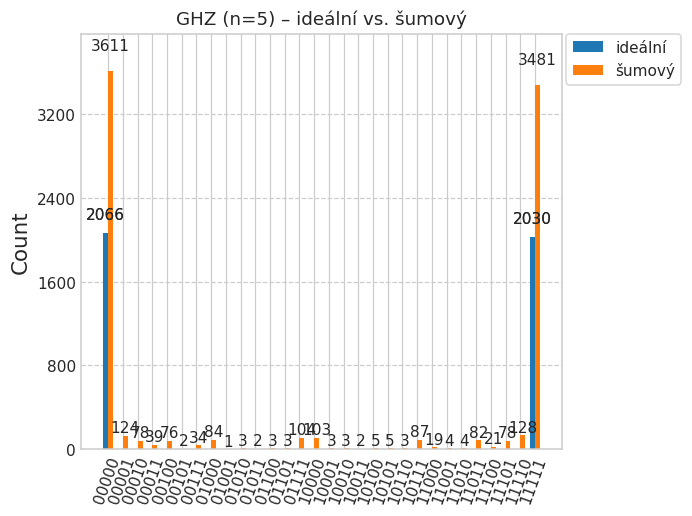

In [82]:
noisy_sim = AerSimulator(noise_model=noise_model)
from qiskit import transpile
qc_t_noisy = transpile(qc_ghz, noisy_sim)
res_noisy = noisy_sim.run(qc_t_noisy, shots=8192).result()
counts_noisy = res_noisy.get_counts()
print(counts_noisy)
from qiskit.visualization import plot_histogram
plot_histogram([counts_ideal, counts_noisy], legend=['ideální','šumový'], title=f'GHZ (n={n_qubits}) – ideální vs. šumový')

In [83]:
def ghz_bitstrings(n):
    zero_str = '0'*n
    one_str  = '1'*n
    return zero_str, one_str

def mass_on_ghz_strings(counts, n):
    total = sum(counts.values())
    z, o = ghz_bitstrings(n)
    return (counts.get(z,0) + counts.get(o,0)) / total if total>0 else 0.0

m_ideal = mass_on_ghz_strings(counts_ideal, n_qubits)
m_noisy = mass_on_ghz_strings(counts_noisy, n_qubits)
print(f'Hmotnost na (00..0, 11..1) – ideální: {m_ideal:.4f}, šumový: {m_noisy:.4f}')

Hmotnost na (00..0, 11..1) – ideální: 1.0000, šumový: 0.8657


## (Volitelně) Stavový vektor ideálního GHZ
Pro ilustraci můžeme zkonstruovat ideální stavový vektor GHZ bez měření a ověřit, že má amplitudy jen na `00…0` a `11…1`.

In [85]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_pure = QuantumCircuit(n_qubits)
qc_pure.h(0)
for i in range(n_qubits-1):
    qc_pure.cx(i, i+1)
sv = Statevector.from_instruction(qc_pure)
sv.draw('latex')

<IPython.core.display.Latex object>

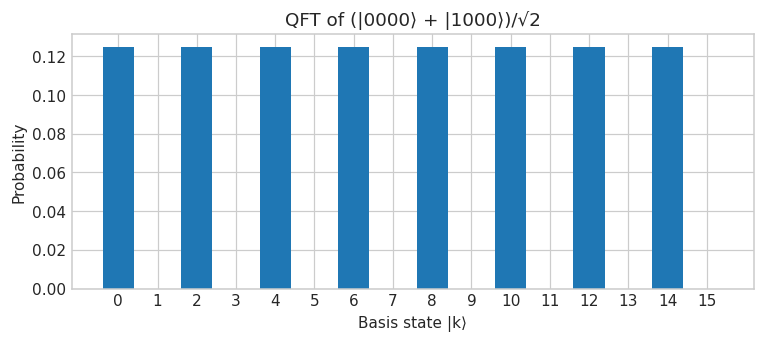

In [86]:
# =============================================
# Quantum Interference Demo – QFT and H–Phase–H
# =============================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ---- PART 1: QFT of (|0000> + |1000>)/√2 ----uvod_do_qc

def qft_matrix(N):
    """Construct the N×N QFT matrix."""
    omega = np.exp(2j * np.pi / N)
    j, k = np.meshgrid(np.arange(N), np.arange(N))
    return omega ** (j * k) / np.sqrt(N)

# 4-qubit system => N = 16
N = 16
qft = qft_matrix(N)

# Input state (|0> + |8>)/√2
psi = np.zeros(N, dtype=complex)
psi[0] = 1 / np.sqrt(2)
psi[8] = 1 / np.sqrt(2)

# Apply QFT
out = qft @ psi
prob = np.abs(out) ** 2

plt.figure(figsize=(8,3))
plt.bar(range(N), prob)
plt.title("QFT of (|0000⟩ + |1000⟩)/√2")
plt.xlabel("Basis state |k⟩")
plt.ylabel("Probability")
plt.xticks(range(0,16))
plt.show()




In [87]:
# ===========================================
# Interactive Interference Visualization
# Circuit: H → Phase(φ) → H
# ===========================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 110})

def H():
    return np.array([[1, 1], [1, -1]]) / np.sqrt(2)

def phase(phi):
    return np.array([[1, 0], [0, np.exp(1j * phi)]])

def interference(phi):
    # Input |0>
    psi0 = np.array([1, 0])
    
    # Apply first H
    psi1 = H() @ psi0
    
    # Apply phase shift
    psi2 = phase(phi) @ psi1
    
    # Final H
    psi3 = H() @ psi2

    # --- Amplitudes (for visualization) ---
    amp_unshifted = psi1[0]
    amp_shifted = psi1[1] * np.exp(1j * phi)
    
    # Extended x-axis for better visualization
    x = np.linspace(0, 4*np.pi, 800)
    wave1 = np.real(np.exp(1j * x)) * np.abs(amp_unshifted)
    wave2 = np.real(np.exp(1j * (x + phi))) * np.abs(amp_shifted)
    interference_wave = wave1 + wave2

    # --- Plot 1: amplitude interference waves ---
    plt.figure(figsize=(9, 4))
    plt.plot(x, wave1, label='Unshifted amplitude', color='C0')
    plt.plot(x, wave2, label='Phase-shifted amplitude', color='C1')
    plt.plot(x, interference_wave, label='Sum (interference)', color='C2', linewidth=2)
    plt.title(f"Amplitude Interference (Phase φ = {phi:.2f} rad)")
    plt.xlabel("Relative phase (arbitrary x)")
    plt.ylabel("Amplitude (real part)")
    plt.ylim(-1.8, 1.8)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # --- Plot 2: output probabilities ---
    probs = np.abs(psi3)**2
    plt.figure(figsize=(5,3))
    plt.bar(['|0⟩','|1⟩'], probs, color=['#4A90E2','#50E3C2'])
    plt.ylim(0, 1)
    plt.title(f"Measurement probabilities after H–Phase({phi:.2f})–H")
    plt.ylabel("Probability")
    plt.grid(axis='y', linestyle=':')
    plt.show()


# Interactive slider for φ
interact(interference, phi=FloatSlider(value=0, min=0, max=2*np.pi, step=0.05, description='Phase φ'));


interactive(children=(FloatSlider(value=0.0, description='Phase φ', max=6.283185307179586, step=0.05), Output(…

# Kvantová Fourierova transformace

In [88]:
# import numpy as np
# import qiskit
# import qiskit_aer
# from qiskit import QuantumCircuit
# from qiskit.visualization import plot_histogram
# from qiskit.circuit.library import QFTGate
# from qiskit_aer import AerSimulator
# from qiskit import QuantumRegister, ClassicalRegister
# from qiskit.circuit.library import QFT

# print(qiskit.version.get_version_info())
# print(qiskit_aer.version.get_version_info())

In [89]:
# QFT
# QFTGate



In [90]:
# Step 1: Map
 
# qubits = 4
# N = 2**qubits
 
 
# qc = QuantumCircuit(qubits)

# # modify the circuit to select diferent basis function
# qc.x(1) 
# # qc.x(0) 
 
 
# # make a copy of the above circuit. (to be used when we apply the QFT in next part)
# qc_qft = qc.copy()
 
 
# qc.measure_all()
# qc.draw("mpl")

In [91]:
# backend = AerSimulator()

# results = backend.run(qc, shots=1000).result()
# counts = results.get_counts()
# plot_histogram(counts)


In [92]:

# qc_qft.compose(QFTGate(qubits), inplace=True)
# qc_qft.measure_all()
# qc_qft.draw("mpl")
# # qc_qft.QFTGate(nqubits=4)
# # # qc_qft.compose(QFTGate(qubits), inplace=True)
# qc_qft.measure_all()
# qc_qft.draw("mpl")



In [93]:
# pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
# qc_isa = pm.run(qc_qft)

In [94]:
# backend = AerSimulator()

# results = backend.run(qc_qft, shots=1000).result()
# counts = results.get_counts()
# plot_histogram(counts)

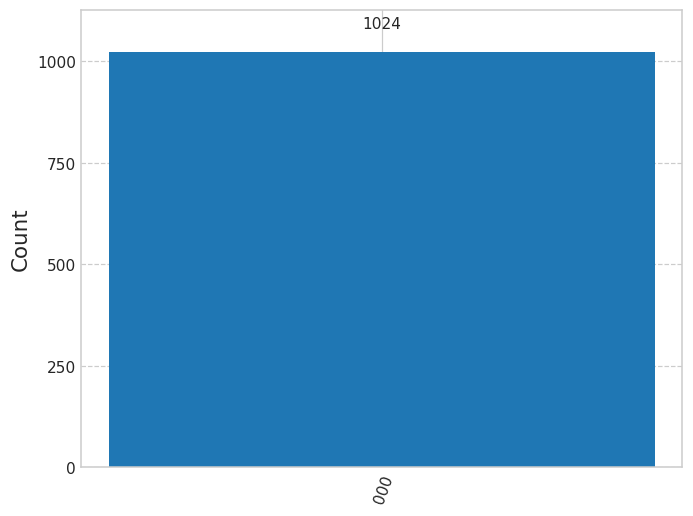

In [95]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create a 3-qubit QFT circuit
n = 3
qc = QuantumCircuit(n)
qc.h(0)                    # Example: put one qubit in superposition
qc.h(1)
qc.h(2)
qc.append(QFTGate(n), range(n))
qc.measure_all()
qc.draw('mpl')

# Run on Aer simulator
sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1024).result()
counts = result.get_counts()

# Show results
plot_histogram(counts)
# plot_histogram(counts)


In [97]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
import numpy as np

# Parametry koherence a časů bran
T1 = 200e-6   # 80 microseconds
T2 = 60e-6   # 60 microseconds
t_1q = 35e-9 # 35 ns
t_2q = 250e-9# 250 ns

# Depolarizační pravděpodobnosti
p_1q = 1.0e-3
p_2q = 1.5e-2

# Čtecí chyba ~2% (symetrická)
p_ro = 0.02

noise_model = NoiseModel()

# 1q: termální relaxace + depolarizace (kompozice)
relax_1q = thermal_relaxation_error(T1, T2, t_1q)
depol_1q = depolarizing_error(p_1q, 1)
err_1q = relax_1q.compose(depol_1q)

# 2q (CX): termální relaxace na obou qubitech + depolarizace dvouqubitová
relax_2q = thermal_relaxation_error(T1, T2, t_2q).tensor(thermal_relaxation_error(T1, T2, t_2q))
depol_2q = depolarizing_error(p_2q, 2)
err_2q = relax_2q.compose(depol_2q)

# Přiřadíme šum k branám
oneq_gates = ['id','x','y','z','h','sx','rx','ry','rz']
for g in oneq_gates:
    noise_model.add_all_qubit_quantum_error(err_1q, g)

twoq_gates = ['cx']
for g in twoq_gates:
    noise_model.add_all_qubit_quantum_error(err_2q, g)

# Čtecí chyba pro každý qubit (2x2 matice chyb)
ro_matrix = [[1-p_ro, p_ro], [p_ro, 1-p_ro]]
noise_model.add_all_qubit_readout_error(ro_matrix)

noise_model



<NoiseModel on ['z', 'cx', 'y', 'ry', 'x', 'rz', 'measure', 'rx', 'h', 'sx', 'id']>

In [98]:
noisy_sim = AerSimulator(noise_model=noise_model)
from qiskit import transpile
qc_t_noisy = transpile(qc, noisy_sim)
res_noisy = noisy_sim.run(qc_t_noisy, shots=8192).result()
counts_noisy = res_noisy.get_counts()
# print(counts_noisy)
# from qiskit.visualization import plot_histogram
# plot_histogram([counts_ideal, counts_noisy], legend=['ideální','šumový'], title=f'GHZ (n={n_qubits}) – ideální vs. šumový')

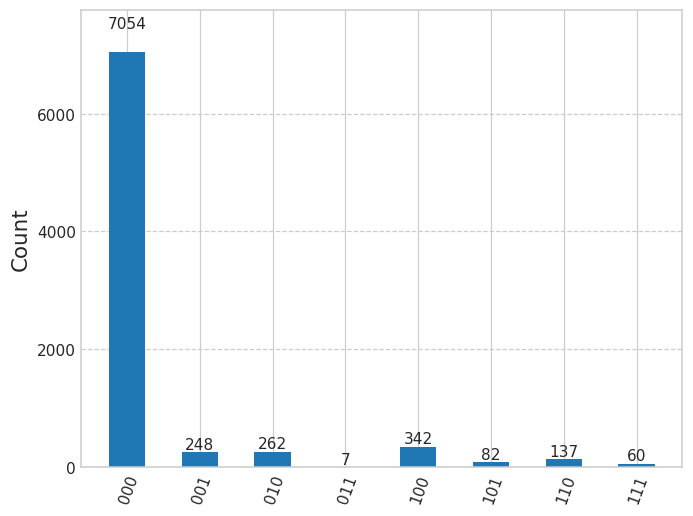

In [99]:
plot_histogram(counts_noisy)
